In [1]:
import util
from models import EEGNet

from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint
from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from tensorflow.keras import utils as np_utils
from scipy.signal import stft
from pyriemann.utils.viz import plot_confusion_matrix

['/Users/bobbeashel/Desktop/CITS4010/Project', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python38.zip', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/lib-dynload', '', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages', '/Users/bobbeashel/Desktop/CITS4010/ARL-EEGMODELS/arl-eegmodels-master']
1.24.3


In [2]:
#training_files = ["A01T", "A02T", "A03T","A04T", "A05T", "A06T", "A07T", "A08T", "A09T"]
#test_files = ["A01E", "A02E", "A03E", "A04E", "A05E", "A06E", "A07E", "A08E", "A09E"]

training_files = ["A01T"]
test_files = ["A01E"]

tmin, tmax = 0.5, 2.5 # seconds before and after stimulus we want to record 
    # From the paper describing dataset
bandpass = [4,40]
baseline = None

amplitude_magnification = 1000 #current best = 1000

X_train_original, Y_train_original, X_test_original, Y_test, chans, kernels, samples, names = util.get_bci_2a(
    training_files, test_files, 
    bandpass = bandpass,
    tmin = tmin, tmax = tmax,
    mode = "gdf",
    amp_mag= amplitude_magnification, 
    baseline=baseline
    )
'''
X= X_train_original
sfreq = 250  # Set your sampling frequency (Hz)
nperseg = 128  # Window length (in samples)
noverlap = 64  # Overlap between windows

# Initialize container: (trials, channels, freqs, times)
trial_count, ch_count, time_len = X.shape
freqs, times, _ = stft(X[0, 0], fs=sfreq, nperseg=nperseg, noverlap=noverlap)
Zxx = np.empty((trial_count, ch_count, len(freqs), len(times)), dtype=complex)

# Apply STFT for each trial & channel
for trial in range(trial_count):
    for ch in range(ch_count):
        f, t, Z = stft(X[trial, ch], fs=sfreq, nperseg=nperseg, noverlap=noverlap)
        Zxx[trial, ch] = Z

# Example plot: Power spectrogram for trial 0, channel 0
plt.figure(figsize=(8, 4))
plt.pcolormesh(t, f, np.abs(Zxx[0, 0])**2, shading='gouraud')
plt.title('STFT Power Spectrogram (Trial 0, Channel 0)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power')
plt.tight_layout()
plt.show()

print(Zxx.shape)
# Trials x Channels x Frequency Bins x Windows
X_train_original = Zxx'''

def convert_to_time_frequency(X_train, X_test, sfreq=250, nperseg=64, noverlap=32):
    def compute_stft(X):
        trial_count, ch_count, time_len = X.shape
        # Correct unpacking of STFT
        freqs, times, _ = stft(X[0, 0], fs=sfreq, nperseg=nperseg, noverlap=noverlap)

        Zxx = np.empty((trial_count, ch_count, len(freqs), len(times)), dtype=np.complex64)

        for trial in range(trial_count):
            for ch in range(ch_count):
                freqs_tmp, times_tmp, Zxx_tmp = stft(X[trial, ch], fs=sfreq, nperseg=nperseg, noverlap=noverlap)
                Zxx[trial, ch] = Zxx_tmp

        return Zxx, freqs, times

    X_train_tf, freqs, times = compute_stft(X_train)
    X_test_tf, _, _ = compute_stft(X_test)

    return X_train_tf, X_test_tf, freqs, times

X_train_tf, X_test_tf, freqs, times = convert_to_time_frequency(X_train_original, X_test_original)
print(X_train_tf.shape)  # (288, 22, freqs, times)
print(X_test_tf.shape)   # (288, 22, freqs, times)

Extracting EDF parameters from /Users/bobbeashel/Desktop/CITS4010/Project/data/BCICIV_2a_gdf/A01T.gdf...
GDF file detected


Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['769', '770', '771', '772']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped
Extracting EDF parameters from /Users/bobbeashel/Desktop/CITS4010/Project/data/BCICIV_2a_gdf/A01E.gdf...
GDF file detected
Setting channel info structure...
Could not determ

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:147: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.
/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['783']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:147: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.


(288, 22, 33, 17)
(288, 22, 33, 17)


In [3]:
# take 50/25/25 percent of the data to train/validate/test
#X_train, X_temp, Y_train, Y_temp = train_test_split(X_test, Y_test, test_size=0.5, stratify=Y_train)
#X_validate, X_test, Y_validate, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, stratify=Y_temp)


#X_train, X_validate, Y_train, Y_validate = train_test_split(X_train_original, Y_train_original, test_size=0.2, stratify=Y_train_original)
#X_train      = X_train.reshape(X_train.shape[0], chans, samples, kernels)
#X_validate   = X_validate.reshape(X_validate.shape[0], chans, samples, kernels)
#X_test       = X_test_original.reshape(X_test_original.shape[0], chans, samples, kernels)

X_train, X_validate, Y_train, Y_validate = train_test_split(X_train_tf, Y_train_original, test_size=0.2, stratify=Y_train_original)
X_test       = X_test_tf
print(X_train.shape, X_test.shape)


print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

Y_train = np_utils.to_categorical(Y_train) # One hot encoding format for probabilistic classification
Y_validate = np_utils.to_categorical(Y_validate) # One hot encoding format for probabilistic classification
Y_test = np_utils.to_categorical(Y_test) # One hot encoding format for probabilistic classification

# 2) Standardize per-channel (over time & trials)
mean  = X_train.mean(axis = (0,2), keepdims=True)
std   = X_train.std(axis = (0,2), keepdims=True)
X_train    = (X_train   - mean) / std
X_validate = (X_validate- mean) / std
X_test     = (X_test    - mean) / std

# configure the EEGNet-8,2,16 model with kernel length of 32 samples (other 
# model configurations may do better, but this is a good starting point)
self_model = EEGNet(nb_classes = 4, Chans = chans, Samples = samples, 
               dropoutRate = 0.5, kernLength = 32, F1 = 8, D = 2, F2 = 16, 
               dropoutType = 'Dropout')

# compile the model and set the optimizers
self_model.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics = ['accuracy'])

numParams    = self_model.count_params()    

# set a valid path for your system to record model checkpoints
checkpointer = ModelCheckpoint(filepath='/tmp/checkpoint.h5', verbose=1, save_best_only=True)

###############################################################################
# if the classification task was imbalanced (significantly more trials in one
# class versus the others) you can assign a weight to each class during 
# optimization to balance it out. This data is approximately balanced so we 
# don't need to do this, but is shown here for illustration/completeness. 
###############################################################################

class_weights = {0:1, 1:1, 2:1, 3:1}

(230, 22, 33, 17) (288, 22, 33, 17)
(230, 22, 33, 17) (288, 22, 33, 17)
(230,) (288,)


In [4]:
#Verbose can change
fittedModel = self_model.fit(X_train, Y_train, batch_size = 16, epochs = 300, 
                        verbose = 0, validation_data=(X_validate, Y_validate),
                        callbacks=[checkpointer])

ValueError: in user code:

    File "/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py", line 1338, in train_function  *
        return step_function(self, iterator)
    File "/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py", line 1322, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py", line 1303, in run_step  **
        outputs = model.train_step(data)
    File "/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py", line 1080, in train_step
        y_pred = self(x, training=True)
    File "/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/Users/bobbea

In [ ]:
def accept_confident_probabilities(probs, k, Y_test):
    # Get indices of sorted probabilities (descending)
    sorted_indices = np.argsort(-probs, axis=1)

    # Highest and second-highest probabilities
    top1_probs = probs[np.arange(len(probs)), sorted_indices[:, 0]]
    top2_probs = probs[np.arange(len(probs)), sorted_indices[:, 1]]

    # Apply condition: only keep prediction if top1 >= 2 * top2
    preds = sorted_indices[:, 0]
    mask = top1_probs >= k * top2_probs
    print(len(mask))

    made_preds = preds[mask]
    Y_test_new = Y_test[mask]
    return made_preds, Y_test_new, mask

In [ ]:
import pandas as pd
import seaborn as sns
def plot_all_predicted_probabilities(probs, class_names=None):
    """
    Plot the distribution of maximum predicted probabilities for each instance,
    including both individual dots (stripplot) and summary (boxplot).
    
    Args:
        probs: np.ndarray of shape (n_samples, n_classes)
    """
    max_probs = probs.max(axis=1)  # get top-1 probability for each sample

    plt.figure(figsize=(12, 5))
    
    # Create both stripplot and boxplot on the same axis
    sns.stripplot(x=max_probs, orient='h', jitter=0.2, alpha=0.5, color='dodgerblue', label='Individual Samples')
    sns.boxplot(x=max_probs, orient='h', color='lightgray', width=0.3, fliersize=0, linewidth=1)

    plt.xlabel('Top-1 Predicted Probability')
    plt.title('Top-1 Confidence Distribution (with Boxplot)')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.legend()
    plt.show()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 22, 500, 1)]      0         
                                                                 
 conv2d_2 (Conv2D)           (None, 22, 500, 8)        256       
                                                                 
 batch_normalization_6 (Bat  (None, 22, 500, 8)        32        
 chNormalization)                                                
                                                                 
 depthwise_conv2d_2 (Depthw  (None, 1, 500, 16)        352       
 iseConv2D)                                                      
                                                                 
 batch_normalization_7 (Bat  (None, 1, 500, 16)        64        
 chNormalization)                                                
                                                           

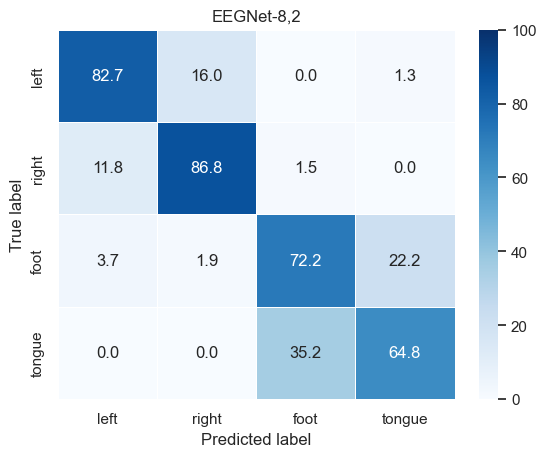

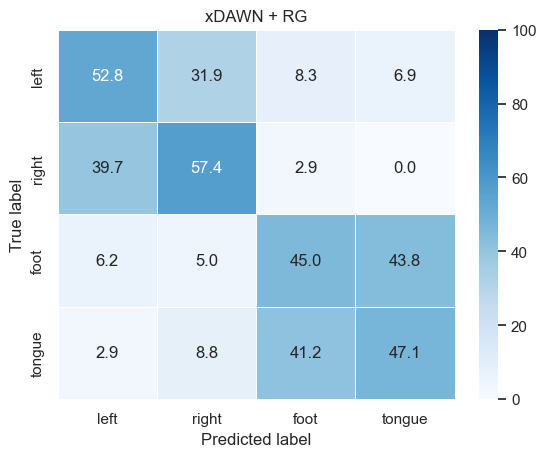

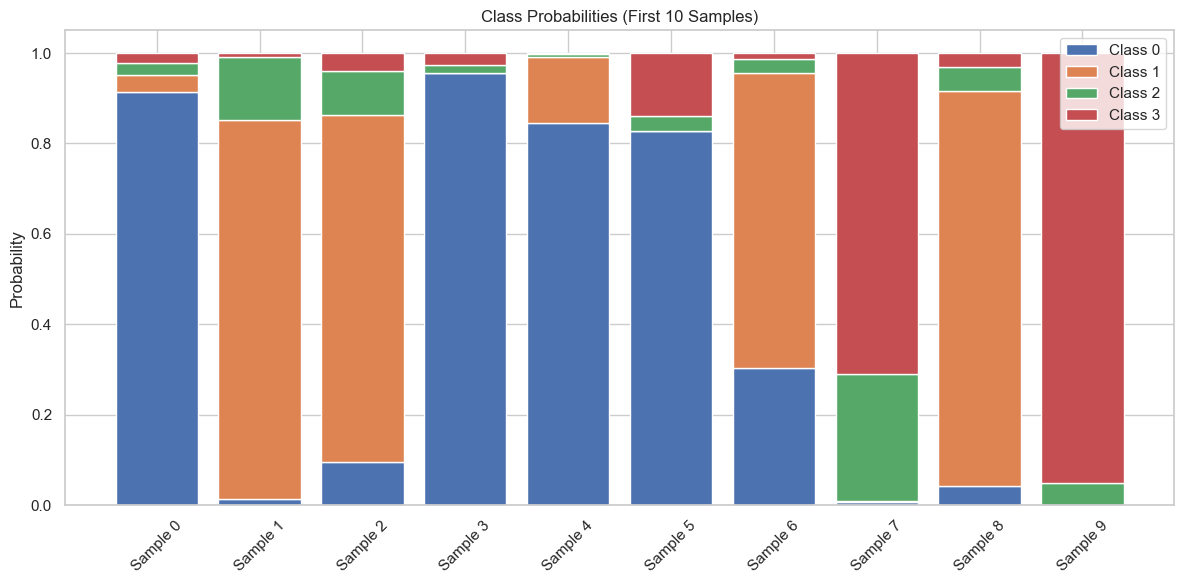

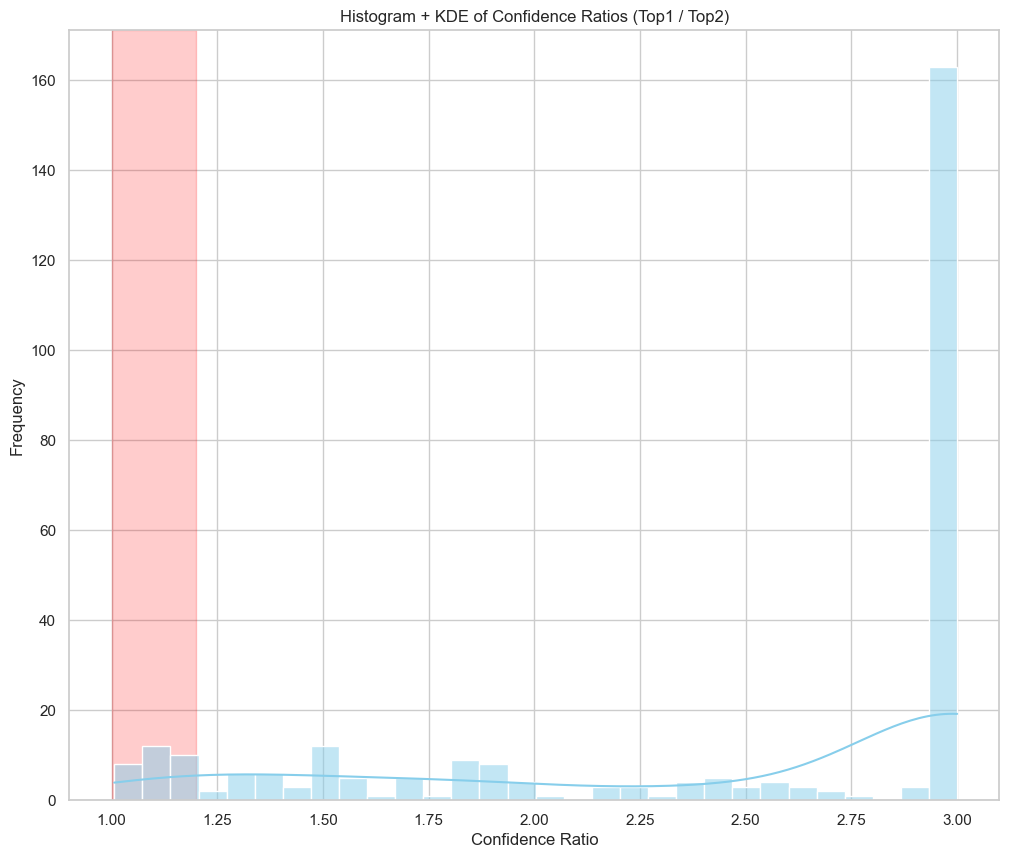

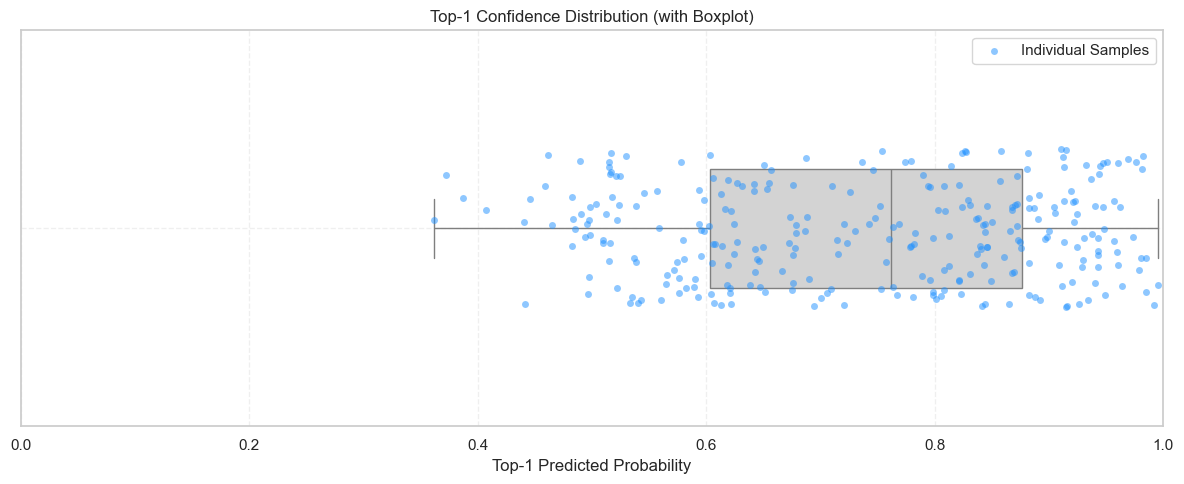

Average confidence of selected class:  0.73664826


In [ ]:
#########################################################################################################

# load optimal weights
self_model.load_weights('/tmp/checkpoint.h5')

#predict
print(self_model.summary())
probs = self_model.predict(X_test)

#k=1.2 # If k is 1, just accept all highest probs (preds       = probs.argmax(axis = -1)  )
# k >= 1

#preds, Y_test, mask = accept_confident_probabilities(probs, k, Y_test)
#omitted = X_test[~mask]

preds = probs.argmax(axis = -1)

acc = np.mean(preds == Y_test.argmax(axis=-1))
print("Classification accuracy EEGNet: %f " % (acc))
#print(len(omitted), " samples deleted")

############################# xDAWN + RG Portion ##############################

# code is taken from PyRiemann's ERP sample script, which is decoding in 
# the tangent space with a logistic regression

n_components = 2  # pick some components

# set up sklearn pipeline
clf = make_pipeline(XdawnCovariances(n_components),
                    TangentSpace(metric='riemann'),
                    LogisticRegression())
 
preds_rg     = np.zeros(len(Y_test))

# reshape back to (trials, channels, samples)
X_train_reshaped      = X_train.reshape(X_train.shape[0], chans, samples)
X_test_reshaped       = X_test.reshape(X_test.shape[0], chans, samples)

# train a classifier with xDAWN spatial filtering + Riemannian Geometry (RG)
# labels need to be back in single-column format
clf.fit(X_train_reshaped, Y_train.argmax(axis = -1))
preds_rg     = clf.predict(X_test_reshaped)

# Printing the results
acc2         = np.mean(preds_rg == Y_test.argmax(axis = -1))
print("Classification accuracy xDAWN + RG: %f " % (acc2))

# plot the confusion matrices for both classifiers

plt.figure(0)
plot_confusion_matrix(preds, Y_test.argmax(axis = -1), names, title = 'EEGNet-8,2')


plt.figure(1)
plot_confusion_matrix(preds_rg, Y_test.argmax(axis = -1), names, title = 'xDAWN + RG')

plt.show()

# Show only the first 10 samples for clarity
samples_to_plot = 10
util.plot_predicted_probs(probs, samples_to_plot)
util.plot_prediction_confidence(probs)
plot_all_predicted_probabilities(probs)
print("Average confidence of selected class: ", np.mean(probs.max(axis=1)))
